In [4]:
!pip install rich
!pip install ndjson
!pip install SPARQLWrapper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.9/531.9 kB 5.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 24.8 MB/s eta 0:00:00


In [5]:
from rich.progress import Progress, track
from rich import print
import json, sqlite3, os, sys, random, gzip, rich, ndjson
import re
from SPARQLWrapper import SPARQLWrapper, JSON, POST
import pickle
from collections import Counter
import pandas as pd

# RELOAD Variables

In [6]:
def reload_vars(filename):
    this_var = None
    with open(filename, 'rb') as file:
        this_var = pickle.load(file)
        
    return this_var

In [7]:
DDB = reload_vars('data/vars/DDB-20230810.pkl')
print(len(DDB))

12672598

In [8]:
DDB['X4DLZTZUIPLDGGJURXV5EAFHJIW7YX2K']

{'@id': 'http://www.deutsche-digitale-bibliothek.de/item/X4DLZTZUIPLDGGJURXV5EAFHJIW7YX2K',
 '@type': ['http://www.europeana.eu/schemas/edm/ProvidedCHO'],
 'http://purl.org/dc/elements/1.1/creator': [{'@language': 'zxx',
   '@value': 'Deventer, Hendrik van'}],
 'http://purl.org/dc/elements/1.1/description': [{'@language': 'ger',
   '@value': 'München, Bayerische Staatsbibliothek -- Res/A.obst. 8'}],
 'http://purl.org/dc/elements/1.1/identifier': [{'@value': 'http://mdz-nbn-resolving.de/urn:nbn:de:bvb:12-bsb00075127-7'},
  {'@value': '(OCoLC)166005765'},
  {'@value': '(DE-599)BVBBV001405202'}],
 'http://purl.org/dc/elements/1.1/language': [{'@value': 'ger'}],
 'http://purl.org/dc/elements/1.1/publisher': [{'@language': 'zxx',
   '@value': 'Cröker'}],
 'http://purl.org/dc/elements/1.1/subject': [{'@language': 'ger',
   '@value': 'Gynäkologie'},
  {'@language': 'ger', '@value': 'Medizin'}],
 'http://purl.org/dc/elements/1.1/title': [{'@language': 'ger',
   '@value': 'Henrici à Deventer, M

In [24]:
PREFIXES = reload_vars('data/vars/PREFIXES.pkl')
print(len(PREFIXES))

38

In [91]:
PREDICATES = reload_vars('data/vars/PREDICATES-20230810.pkl')
print(len(PREDICATES))

34

In [23]:
EVENT = reload_vars('data/vars/EVENT-20230810.pkl')
print(len(EVENT))

10580491

In [8]:
AGENT = reload_vars('data/vars/AGENT-20230810.pkl')
print(len(AGENT))

7466295

In [5]:
PRIMARY_HTYPES = reload_vars('data/vars/PRIMARY_HTYPES-20230810.pkl')
print(len(PRIMARY_HTYPES))

19

In [6]:
CHILD_HTYPES = reload_vars('data/vars/CHILD_HTYPES-20230810.pkl')
print(len(CHILD_HTYPES))

28

# PICKLE Variables

In [118]:
def pkl_vars(varname, filename):
    with open(filename, 'wb') as file:
        pickle.dump(varname, file)

In [14]:
pkl_vars(DDB, 'data/vars/DDB-20230810.pkl')

In [15]:
pkl_vars(EVENT, 'data/vars/EVENT-20230810.pkl')

In [21]:
pkl_vars(AGENT, 'data/vars/AGENT-20230810.pkl')

In [22]:
pkl_vars(PLACE, 'data/vars/PLACE-20230810.pkl')

In [23]:
pkl_vars(CONCEPT, 'data/vars/CONCEPT-20230810.pkl')

In [59]:
pkl_vars(DDB_LANG_TITLES, 'data/vars/DDB_LANG_TITLES-20230810.pkl')

In [60]:
pkl_vars(DDB_LANGS, 'data/vars/DDB_LANGS-20230810.pkl')

In [70]:
pkl_vars(PREDICATES, 'data/vars/PREDICATES-20230810.pkl')

In [119]:
pkl_vars(PRIMARY_HTYPES, 'data/vars/PRIMARY_HTYPES-20230810.pkl')

In [120]:
pkl_vars(CHILD_HTYPES, 'data/vars/CHILD_HTYPES-20230810.pkl')

# START

```
ann@ise-d-teach02:~/fiz-ddb/data/obj-ids$ wc -l sec02-all-20230809.txt 
15396379 sec02-all-20230809.txt
```

In [12]:
import ndjson
DDB = {}
EVENT = {}
AGENT = {}
PLACE = {}
CONCEPT = {}
no_type_count = 0
with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Processing ndjson files [%s]" % (91), total=91)

    for i in range(90):
        progress.update(task1, advance=1)
        filename = f'data/J/{i}.ndjson'
        print(f'Loading {filename}')
        for obj in ndjson.load(open(filename)):
            #if not 'http://www.europeana.eu/schemas/edm/type' in obj and \
                #obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/ProvidedCHO':

            if obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Event':
                EVENT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Agent':
                AGENT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Place':
                PLACE[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.w3.org/2004/02/skos/core#Concept':
                CONCEPT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/ProvidedCHO':
                if not 'http://www.europeana.eu/schemas/edm/type' in obj:
                    no_type_count += 1
                elif obj['http://www.europeana.eu/schemas/edm/type'][0]['@value'] == 'TEXT':
                    DDB[obj["@id"].split('/')[-1]] = obj

        print(f'[{len(DDB):,}] objects loaded!')
        print(f'[{len(EVENT):,}] events loaded!')
        print(f'[{len(AGENT):,}] agents loaded!')
        print(f'[{len(PLACE):,}] places loaded!')
        print(f'[{len(CONCEPT):,}] concepts loaded!')
        print(f'[{no_type_count:,}] objects without edm:type!')

Output()

Loading data/J/0.ndjson

[30,189] objects without edm:type!

Loading data/J/1.ndjson

[185,044] objects loaded!

...

[1,489,982] places loaded!

[5,663,194] concepts loaded!

[2,684,609] objects without edm:type!

Loading data/J/89.ndjson

[2,714,778] objects without edm:type!

- [8,309,339] objects loaded!
- [9,326,147] events loaded!
- [6,222,719] agents loaded!
- [1,489,982] places loaded!
- [5,663,194] concepts loaded!
- [2,714,778] objects without edm:type!

In [1]:
DDB['X4DLZTZUIPLDGGJURXV5EAFHJIW7YX2K']

NameError: name 'DDB' is not defined

### Additional Data

In [13]:
no_type_count = 0
with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Processing ndjson files [%s]" % (91), total=91)

    for i in range(90):
        progress.update(task1, advance=1)
        filename = f'data/J-20230809/{i}.ndjson'
        print(f'Loading {filename}')
        for obj in ndjson.load(open(filename)):
            #if not 'http://www.europeana.eu/schemas/edm/type' in obj and \
                #obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/ProvidedCHO':

            if obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Event':
                EVENT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Agent':
                AGENT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/Place':
                PLACE[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.w3.org/2004/02/skos/core#Concept':
                CONCEPT[obj["@id"]] = obj
            elif obj['@type'][0] == 'http://www.europeana.eu/schemas/edm/ProvidedCHO':
                if not 'http://www.europeana.eu/schemas/edm/type' in obj:
                    no_type_count += 1
                elif obj['http://www.europeana.eu/schemas/edm/type'][0]['@value'] == 'TEXT':
                    DDB[obj["@id"].split('/')[-1]] = obj

        print(f'[{len(DDB):,}] objects loaded!')
        print(f'[{len(EVENT):,}] events loaded!')
        print(f'[{len(AGENT):,}] agents loaded!')
        print(f'[{len(PLACE):,}] places loaded!')
        print(f'[{len(CONCEPT):,}] concepts loaded!')
        print(f'[{no_type_count:,}] objects without edm:type!')

Output()

Loading data/J-20230809/0.ndjson

[8,450,661] objects loaded!

[9,444,892] events loaded!

[6,300,052] agents loaded!

...

[10,580,491] events loaded!

[7,466,295] agents loaded!

[1,605,055] places loaded!

[6,398,659] concepts loaded!

[426,038] objects without edm:type!

- [12,672,598] objects loaded!
- [10,580,491] events loaded!
- [7,466,295] agents loaded!
- [1,605,055] places loaded!
- [6,398,659] concepts loaded!
- [426,038] objects without edm:type!

## New Sector 2 IDs

In [24]:
OLD_IDS = []
results = {}
with open('data/sector2.json', 'r') as f:
    results = json.load(f)

for elem in results['response']['docs']:
    OLD_IDS.append(elem['id'])
print(len(OLD_IDS))

11673194

In [32]:
NEW_IDS = []
with open('data/sec02-all-20230809.txt', 'r') as f:
    for line in f.readlines():
        line = line.strip()
        if not line:
            continue
        NEW_IDS.append(line)
NEW_IDS = list(set(NEW_IDS))
print(len(NEW_IDS))

15396378

In [33]:
DIFF_IDS = set(NEW_IDS).difference(set(OLD_IDS))
print(len(DIFF_IDS))

4856227

In [37]:
new_list = []
for objid in DIFF_IDS:
    new_list.append({"id": objid})

In [38]:
results['responseHeader']['params']['rows'] = 4856227
results['response']['numFound'] = 4856227
results['response']['docs'] = new_list
with open('data/sector2-new-20230809.json', 'w') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

# HIERARCHY TYPES

In [114]:
def get_ddb_htypes(details):
    htypes_dict = {
        "htype_001": "Abschnitt",
        "htype_002": "Anhang",
        "htype_003": "Beigefügtes oder enthaltenes Werk",
        "htype_004": "Annotation",
        "htype_005": "Anrede",
        "htype_006": "Aufsatz",
        "htype_007": "Band",
        "htype_008": "Beilage",
        "htype_009": "Einleitung",
        "htype_010": "Eintrag",
        "htype_011": "Faszikel",
        "htype_012": "Fragment",
        "htype_013": "Handschrift",
        "htype_014": "Heft",
        "htype_015": "Illustration",
        "htype_016": "Index",
        "htype_017": "Inhaltsverzeichnis",
        "htype_018": "Kapitel",
        "htype_019": "Karte",
        "htype_020": "Mehrbändiges Werk",
        "htype_021": "Monografie",
        "htype_022": "Musik",
        "htype_023": "Fortlaufendes Sammelwerk",
        "htype_024": "Privilegie",
        "htype_025": "Rezension",
        "htype_026": "Text",
        "htype_027": "Vers",
        "htype_028": "Vorwort",
        "htype_029": "Widmung",
        "htype_030": "Bestand,Findbuch Collection",
        "htype_031": "Gliederung, Findbuch Class",
        "htype_032": "Serie, Findbuch Serie",
        "htype_033": "Unterserie",
        "htype_034": "Archivale, Findbuch File",
        "htype_035": "Teil, Findbuch Item",
        "htype_036": "Bestandsserie",
        "htype_037": "Bestandsklassifikation",
        "htype_038": "Brief",
        "htype_039": "Konvolut",
        "htype_040": "Mappe",
        "htype_041": "Archiv",
        "htype_044": "Zeitung",
        "htype_045": "Jahrgang",
        "htype_046": "Monat",
        "htype_047": "Tag",
        "htype_048": "Tektonik",
        "ht001": "Abschnitt",
        "ht002": "Anhang",
        "ht003": "Beigefügtes oder enthaltenes Werk",
        "ht004": "Annotation",
        "ht005": "Anrede",
        "ht006": "Aufsatz",
        "ht007": "Band",
        "ht008": "Beilage",
        "ht009": "Einleitung",
        "ht010": "Eintrag",
        "ht011": "Faszikel",
        "ht012": "Fragment",
        "ht013": "Handschrift",
        "ht014": "Heft",
        "ht015": "Illustration",
        "ht016": "Index",
        "ht017": "Inhaltsverzeichnis",
        "ht018": "Kapitel",
        "ht019": "Karte",
        "ht020": "Mehrbändiges Werk",
        "ht021": "Monografie",
        "ht022": "Musik",
        "ht023": "Fortlaufendes Sammelwerk",
        "ht024": "Privilegie",
        "ht025": "Rezension",
        "ht026": "Text",
        "ht027": "Vers",
        "ht028": "Vorwort",
        "ht029": "Widmung",
        "ht030": "Bestand,Findbuch Collection",
        "ht031": "Gliederung, Findbuch Class",
        "ht032": "Serie, Findbuch Serie",
        "ht033": "Unterserie",
        "ht034": "Archivale, Findbuch File",
        "ht035": "Teil, Findbuch Item",
        "ht036": "Bestandsserie",
        "ht037": "Bestandsklassifikation",
        "ht038": "Brief",
        "ht039": "Konvolut",
        "ht040": "Mappe",
        "ht041": "Archiv",
        "ht044": "Zeitung",
        "ht045": "Jahrgang",
        "ht046": "Monat",
        "ht047": "Tag",
        "ht048": "Tektonik"
    }
    types = ''
    htype_str = ''
    
    if 'http://www.deutsche-digitale-bibliothek.de/edm/hierarchyType' in details:
        htype_str = details['http://www.deutsche-digitale-bibliothek.de/edm/hierarchyType'][0]['@value']
        types = htypes_dict[htype_str]
    else:
        for edm_types in details.get('http://www.europeana.eu/schemas/edm/hasType', []):
            for edm_type in edm_types.values():            
                if edm_type.startswith('http://ddb.vocnet.org/hierarchietyp/'):
                    htype_str = edm_type.split('/')[-1]
                    htype_str.replace('ype_', '')
                    types = htypes_dict[htype_str]
        
        if not htype_str:
            htype_str = 'UNK'
            types = 'UNK'

    return htype_str, types

get_ddb_htypes(DDB['G73PVFUUV7JYCZL6AWDKVVXLWDL36VJY'])

('ht021', 'Monografie')

In [116]:
filter_props = ['http://purl.org/dc/terms/isPartOf']
PRIMARY_HTYPES = Counter()
CHILD_HTYPES = Counter()

def per_item_htypes():
    global DDB
    global PRIMARY_HTYPES
    global CHILD_HTYPES
    with Progress() as progress:
        task1 = progress.add_task(
            "[blue] Loading DDB titles [%s]" % (len(DDB)), total=len(DDB))
    
        for obj_id, details in DDB.items():
            progress.update(task1, advance=1)
            
            (_, htype) = get_ddb_htypes(details)
            
            # PARTIAL or Child Object
            if set(filter_props).intersection(set(list(details.keys()))):
                CHILD_HTYPES.update({htype: 1})
            else:
                PRIMARY_HTYPES.update({htype: 1})
per_item_htypes()

Output()

In [121]:
print(f'Primary Objects: {sum(x[1] for x in PRIMARY_HTYPES.most_common()):,d}')
print(f'Secondary Objects: {sum(x[1] for x in CHILD_HTYPES.most_common()):,d}')

Primary Objects: 4,558,530

Secondary Objects: 8,114,068

In [8]:
import pandas as pd

df_primary_htypes = pd.DataFrame.from_dict(dict(PRIMARY_HTYPES.most_common()), orient='index').reset_index()
# inplace=False: don't save new column names

df_primary_htypes.set_axis(['htype', 'obj_count'], axis=1, inplace=True)
print('Primary HTypes')
df_primary_htypes.head()

Primary HTypes

,htype,obj_count
0,Heft,2286864
1,Monografie,1839140
2,Abschnitt,226986
3,UNK,71955
4,Beilage,41106


In [9]:
df_primary_htypes['percent'] = round(df_primary_htypes['obj_count'] / sum(x[1] for x in PRIMARY_HTYPES.most_common()) * 100, 2)
df_primary_htypes = df_primary_htypes.drop(df_primary_htypes[df_primary_htypes.percent <= 0].index)

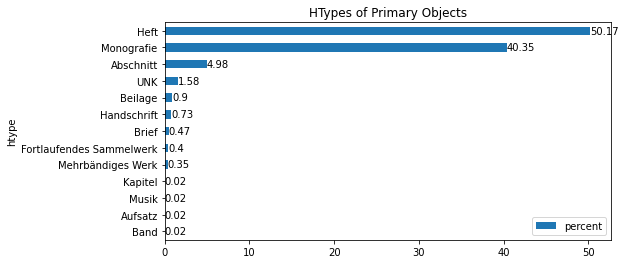

In [13]:
#ax = df_primary_htypes.plot(x='htype', y='percent', kind='barh', title='HTypes of Primary Objects')
#ax.bar_label(ax.containers[0])

ax = df_primary_htypes.plot(x='htype', y='percent', kind='barh', title='HTypes of Primary Objects', figsize=(8,4))
ax.bar_label(ax.containers[0])
ax.invert_yaxis()
ax.legend(loc='lower right')

In [14]:
df_child_htypes = pd.DataFrame.from_dict(dict(CHILD_HTYPES.most_common()), orient='index').reset_index()
df_child_htypes.set_axis(['htype', 'obj_count'], axis=1, inplace=True)
print('Child HTypes')
df_child_htypes.head()

Child HTypes

,htype,obj_count
0,Kapitel,2428739
1,Abschnitt,1843314
2,Aufsatz,1201740
3,Heft,1087501
4,Band,570312


In [18]:
df_child_htypes['percent'] = round(df_child_htypes['obj_count'] / sum(x[1] for x in CHILD_HTYPES.most_common()) * 100, 2)
df_child_htypes = df_child_htypes.drop(df_child_htypes[df_child_htypes.percent <= 1].index)

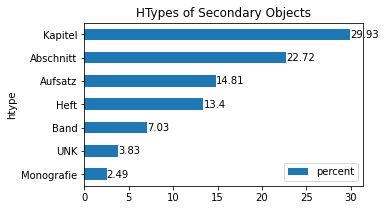

In [22]:
#ax = df_child_htypes.plot(x='htype', y='percent', kind='barh', title='HTypes of Secondary Objects')
#ax.bar_label(ax.containers[0])

ax = df_child_htypes.plot(x='htype', y='percent', kind='barh', title='HTypes of Secondary Objects', figsize=(5,3))
ax.bar_label(ax.containers[0])
ax.invert_yaxis()
ax.legend(loc='lower right')

# TITLES
[TODO] - Which htypes to exclude?

### Methods

In [45]:
def get_ddb_types(details):
    types = list()
    for dc_type in details.get('http://purl.org/dc/elements/1.1/type', []):
        if not '@value' in dc_type:
            continue
        types.append(str(dc_type['@value']).lower())
    
    return types

get_ddb_types(DDB['G73PVFUUV7JYCZL6AWDKVVXLWDL36VJY'])

['gelegenheitsschrift:promotion', 'lyrik', 'monografie']

In [46]:
def get_langcode_3to2(code3):
    code2 = None
    try:
        code2 = pycountry.languages.get(alpha_3=code3).alpha_2
    except:
        return 'de'
    return code2

get_langcode_3to2('lat')

'de'

### Variables

In [56]:
DDB_LANGS = {}
DDB_LANG_TITLES = {}

In [58]:
lang_prop = 'http://purl.org/dc/terms/language'
title_props = ['http://purl.org/dc/elements/1.1/title',
               'http://purl.org/dc/elements/1.1/alternative']

included_htypes = ['monografie', 'kapitel', 'abschnitt', 'handschrift', 'mehrbändiges werk', 'aufsatz', 'band', 'musik', 'rezension']

with Progress() as progress:
    task1 = progress.add_task("[blue] Loading DDB titles [%s]" % (len(DDB)), total=len(DDB))

    progress_count = 0
    for obj_id, details in DDB.items():
        progress.update(task1, advance=1)
        progress_count += 1

        # get language code
        orig_langs = []            

        if lang_prop in details:
            for lang_code in details[lang_prop]:
                lang_code = lang_code['@id'].split('/')[-1]
                short_code = get_langcode_3to2(lang_code)
                orig_langs.append(short_code)
                if not lang_code in DDB_LANGS:
                    DDB_LANGS[lang_code] = []
                DDB_LANGS[lang_code].append(obj_id)
            #print(orig_langs)
        
        props = set(title_props).intersection(set(list(details.keys())))

        for prop in props:
            for title in details[prop]:               
                #langid_code = langid.classify(title['@value'])[0]
                #lstmlid_code = predict(title['@value'])


                #print(langid_code, lstmlid_code)

                if not obj_id in DDB_LANG_TITLES:
                    DDB_LANG_TITLES[obj_id] = [{'title': title,
                                        'lang': orig_langs,
                                        #'langid': langid_code,
                                        #'lstmlid': lstmlid_code
                                               }]
                else:
                    DDB_LANG_TITLES[obj_id].append({'title': title,
                                        'lang': orig_langs,
                                        #'langid': langid_code,
                                        #'lstmlid': lstmlid_code
                                                   })
        '''
        if orig_langs:
            if langid_code in orig_langs:
                LANGID_TP += 1

            TOTAL_LANG_TITLES += 1

        if progress_count % 20000 == 0:
            print(f'[{progress_count:,d}] langid: {LANGID_TP:,d} ({LANGID_TP/TOTAL_LANG_TITLES*100:.2f}%)')
            print(f'DDB languages: [{len(DDB_LANGS)}]')
        '''

Output()

# Languages

In [61]:
LANGUAGES = Counter()

def count_languages():
    global DDB
    global LANGUAGES
    with Progress() as progress:
        task1 = progress.add_task(
            "[blue] Loading DDB objects [%s]" % (len(DDB)), total=len(DDB))
    
        for obj_id in DDB.keys():
            details = DDB[obj_id]
            progress.update(task1, advance=1)
            
            if not "http://purl.org/dc/elements/1.1/language" in details.keys():
                LANGUAGES.update({'und': 1})
                continue
                
            #print(details['http://purl.org/dc/elements/1.1/language'])
            
            for lang in details['http://purl.org/dc/elements/1.1/language']:
                LANGUAGES.update({lang['@value']: 1})
            
count_languages()

Output()

In [63]:
print(len(LANGUAGES.most_common()))
und_language = LANGUAGES['und'] + LANGUAGES['zxx']
print(f'no language tags: {und_language:,d} ({und_language/len(DDB)*100:.02f}%)')

278

no language tags: 1,735,096 (13.69%)

# Properties

In [61]:
def get_prefix_prop(predicate):
    namespaces = dict((url, prefix) for prefix, url in PREFIXES.items())
    tokens = []
    url = ''
    
    if '#' in predicate:
        tokens = predicate.split('#')
        url = tokens[0] + '#'
    else:
        tokens = predicate.split('/')
        url = '/'.join(tokens[:-1]) + '/'

    prefix = namespaces.get(url, url)
    
    return prefix + ':'  + tokens[-1]

get_prefix_prop('http://purl.org/dc/terms/isPartOf')

'dcterms:isPartOf'

In [90]:
PREDICATES = Counter()

def count_predicates():
    global DDB
    global PREDICATES
    with Progress() as progress:
        task1 = progress.add_task(
            "[blue] Loading DDB objects [%s]" % (len(DDB)), total=len(DDB))
    
        for obj_id, details in DDB.items():            
            progress.update(task1, advance=1)

            predicates = list(details.keys())
            for pred in predicates:
                if pred in ['@id', '@type']:
                    continue
                prefix_prop = get_prefix_prop(pred)
                PREDICATES.update({prefix_prop: 1})            
            
count_predicates()

Output()

NameError: name 'get_prefix_prop' is not defined

In [134]:
import pandas as pd

df_predicates = pd.DataFrame.from_dict(dict(PREDICATES.most_common()), orient='index').reset_index()
df_predicates.set_axis(['predicate', 'obj_count'], axis=1, inplace=True)
df_predicates['percent'] = round(df_predicates['obj_count'] / len(DDB) * 100, 2)
df_predicates = df_predicates.drop(df_predicates[df_predicates.percent < 1].index)
df_predicates

,predicate,obj_count,percent
0,dc:title,12672598,100.00
1,edm:type,12672598,100.00
2,dc:type,12448796,98.23
3,edm:hasType,12448633,98.23
4,ddb:hierarchyType,12259381,96.74
5,edm:hasMet,11921319,94.07
6,dc:language,11908667,93.97
7,dcterms:language,11908667,93.97
8,dc:identifier,11776354,92.93
9,dcterms:issued,11492076,90.68


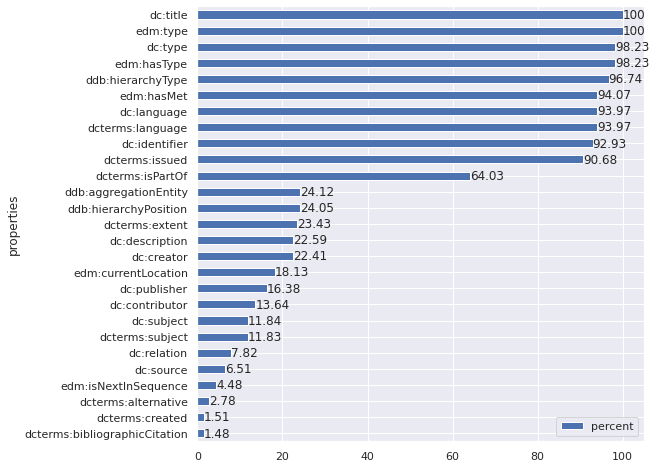

In [135]:
ax = df_predicates.plot(x='predicate', y='percent', kind='barh', figsize=(8,8))
ax.bar_label(ax.containers[0])
ax.invert_yaxis()
ax.set_ylabel("properties")
ax.legend(loc='lower right')

# Linked Open Data

In [20]:
print(PREFIXES['dc'])
print(PREFIXES['dcterms'])
print(PREFIXES['edm'])

http://purl.org/dc/elements/1.1/

http://purl.org/dc/terms/

http://www.europeana.eu/schemas/edm/

In [22]:
CREATORS = Counter()
PUBLISHERS = Counter()
CONTRIBUTORS = Counter()
SUBJECTS = Counter()
DCSUBJECTS = Counter()
LOCATIONS = Counter()


with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Loading DDB objects [%s]" % (len(DDB)), total=len(DDB))

    for obj_id, details in DDB.items():            
        progress.update(task1, advance=1)

        # creator
        values = details.get('http://purl.org/dc/elements/1.1/creator', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                CREATORS.update({domain: 1})

        # publisher
        values = details.get('http://purl.org/dc/elements/1.1/publisher', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                PUBLISHERS.update({domain: 1})


        # contributor
        values = details.get('http://purl.org/dc/elements/1.1/contributors', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                CONTRIBUTORS.update({domain: 1})

        # subject
        values = details.get('http://purl.org/dc/terms/subject', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                SUBJECTS.update({domain: 1})

        values = details.get('http://purl.org/dc/elements/1.1/subject', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                DCSUBJECTS.update({domain: 1})

                
        # locations
        values = details.get('http://www.europeana.eu/schemas/edm/currentLocation', '')
        if not values:
            continue
        for elem in values:
            if '@id' in elem: 
                domain = '/'.join(elem['@id'].split('/')[:3])
                LOCATIONS.update({domain: 1})

Output()

In [32]:
CREATORS.most_common()
print(sum(CREATORS.values())/len(DDB)*100)

2.892382445967275

In [25]:
CONTRIBUTORS.most_common()

[]

In [33]:
PUBLISHERS.most_common()
print(sum(PUBLISHERS.values())/len(DDB)*100)

0.010297809494154236

In [82]:
SUBJECTS = Counter()
DCSUBJECTS = Counter()
DDB_SUBJECTS = Counter()

ext_subj_count = 0
subj_count = 0
with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Loading DDB objects [%s]" % (len(DDB)), total=len(DDB))

    for obj_id, details in DDB.items():            
        progress.update(task1, advance=1)
        found_ext_subj = False
        found_subj = False

        # subject
        values = details.get('http://purl.org/dc/terms/subject', '')
        if not values:
            continue
        for elem in values:
            found_subj = True
            if '@id' in elem:
                if elem['@id'].startswith('http'):
                    domain = '/'.join(elem['@id'].split('/')[:3])                
                    SUBJECTS.update({domain: 1})
                    found_ext_subj = True
                else:
                    SUBJECTS.update({'internal': 1})
                    DDB_SUBJECTS.update({elem['@id']: 1})
                    
        values = details.get('http://purl.org/dc/elements/1.1/subject', '')
        if not values:
            continue
        for elem in values:
            found_subj = True
            if '@value' in elem: 
                DCSUBJECTS.update({elem['@value']: 1})
        
        if found_ext_subj:
            ext_subj_count += 1
        
        if found_subj:
            subj_count += 1

    print(f'Objects with Subject Headings: {subj_count/len(DDB)*100:0.2f}%')
    print(f'Objects with External Subject Headings: {ext_subj_count/len(DDB)*100:0.2f}%')


Output()

Objects with Subject Headings: 11.83%

Objects with External Subject Headings: 5.45%

In [74]:
SUBJECTS.most_common()

[('internal', 4962818),
 ('http://d-nb.info', 2319446),
 ('http://ddb.vocnet.org', 14823),
 ('http://vocab.getty.edu', 1994),
 ('https://www.wikidata.org', 1134)]

In [75]:
DCSUBJECTS.most_common()[:10]

[('Hochschulschrift', 273816),
 ('TIFF, Vers.6.0, 600 dpi, 1 bit (s/w),ITU group; Digitalisierungsvorlage Mikrofilm',
  186729),
 ('Zeitschrift', 138772),
 ('ddc: 090', 79881),
 ('TIFF, Vers.6.0, 600 dpi, 1 bit (s/w),ITU group; Digitalisierungsvorlage: Original',
  43857),
 ('Deutschland', 40228),
 ('Geschichte', 29626),
 ('Politik', 29556),
 ('Wirtschaft', 25974),
 ('Erziehung, Schul- und Bildungswesen', 24432)]

### SUBJECTS

In [4]:
def get_ddb_subj_terms(details):
    terms = list()
    for term in details.get('http://purl.org/dc/elements/1.1/subject', []):
        if not '@value' in term:
            continue
        terms.append(str(term['@value']).lower())
    
    return terms

get_ddb_subj_terms(DDB['4CRMLS65V5WBIC5BJW24CE7YH2XXE7IA'])

NameError: name 'DDB' is not defined

In [80]:
def get_ddb_subj_uri(details):
    terms = list()
    for term in details.get('http://purl.org/dc/terms/subject', []):
        if not '@id' in term:
            continue
        terms.append(str(term['@id']).lower())
    
    return terms

get_ddb_subj_uri(DDB['3AR75UINK5G5ZOGIJOLTN7TF4Z6FFAGU'])

[]

# EVENTS

In [25]:
print(PREFIXES['dc'])
print(PREFIXES['dcterms'])
print(PREFIXES['edm'])

http://purl.org/dc/elements/1.1/

http://purl.org/dc/terms/

http://www.europeana.eu/schemas/edm/

In [26]:
def count_agents(lido_types):

    EVENT_AGENTS = Counter()
    CREATOR_COUNT = 0
    DDB_PERSONS = set()
    LIDO_TYPES = set()

    with Progress() as progress:
        task1 = progress.add_task(
            "[blue] Loading DDB objects [%s]" % (len(DDB)), total=len(DDB))

        for obj_id, details in DDB.items():            
            progress.update(task1, advance=1)


            # event
            values = details.get('http://www.europeana.eu/schemas/edm/hasMet', '')
            for elem in values:
                event_id = elem['@id']

                event_details = EVENT.get(event_id, [])
                if not event_details:
                    continue

                event_type = event_details.get('http://www.europeana.eu/schemas/edm/hasType', '')
                LIDO_TYPES.update([event_type[0]['@id']])

                if not event_type[0]['@id'] in lido_types:
                    continue


                participants = event_details.get('http://www.cidoc-crm.org/rdfs/cidoc_crm_v5.0.2_english_label.rdfs#P11_had_participant', [])
                for agent in participants:
                    CREATOR_COUNT +=1
                    if not '@id' in agent:
                        continue

                    if not agent['@id'].startswith('http'):
                        DDB_PERSONS.update([agent['@id']])
                        continue

                    domain = '/'.join(agent['@id'].split('/')[:3])
                    EVENT_AGENTS.update({domain: 1})                
                
                
    print(EVENT_AGENTS.most_common())
    print(CREATOR_COUNT)
    print(sum(EVENT_AGENTS.values()) / CREATOR_COUNT * 100)
    print(f'DDB Person links: {len(DDB_PERSONS):,d}')

In [32]:
print(LIDO_TYPES)

{
    'http://terminology.lido-schema.org/eventType/publication',
    'http://terminology.lido-schema.org/lido00228',
    'http://terminology.lido-schema.org/eventType/creation',
    'http://terminology.lido-schema.org/lido00012',
    'http://terminology.lido-schema.org/lido00007'
}

### Creators

In [27]:
count_agents(['http://terminology.lido-schema.org/eventType/creation', 'http://terminology.lido-schema.org/lido00012'])

Output()

[
    ('http://d-nb.info', 3001849),
    ('http://uri.hab.de', 3582),
    ('http://kxp.k10plus.de', 1099),
    ('https://opac.uni-erfurt.de', 417),
    ('https://d-nb.info', 112),
    ('http://gso.gbv.de', 41),
    ('http://www.uni-stuttgart.de', 1),
    ('http://viaf.org', 1)
]

6246655

48.139396204848836

DDB Person links: 1,966,516

### Publishers

In [28]:
count_agents(['http://terminology.lido-schema.org/eventType/publication', 'http://terminology.lido-schema.org/lido00228'])

Output()

[('http://d-nb.info', 2027)]

1966662

0.1030680411784028

DDB Person links: 1,097,143

### Producers

In [29]:
count_agents(['http://terminology.lido-schema.org/lido00007'])

Output()

[('http://d-nb.info', 354)]

354

100.0

DDB Person links: 0

## DATES

In [32]:
def get_year_int(year_str):
    matches = re.findall(r'\d{4}', year_str)
    if matches:
        return int(matches[0])
    else:
        return 9999

In [33]:
date_props = ['http://purl.org/dc/terms/date',
               'http://purl.org/dc/terms/created',
               'http://purl.org/dc/terms/issued']


def get_ddb_dates(obj_id, details={}):
    dates = []
    if not details:
        details = DDB[obj_id]
    props = set(date_props).intersection(set(list(details.keys())))
    for prop in props:
        for date in details[prop]:
            value = date.get('@value', '')
            if value and re.findall(r'\d{4}', value):
                dates.append(get_year_int(date['@value']))
    return dates

get_ddb_dates('SPWM52CIKUEGY2OVBAUNBXIBWGGGV7OX')

[1631]

In [41]:
ddb_dates_list = []
YEAR_COUNTER = Counter()

with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Retrieve Year [%s] " % (len(DDB)), total=len(DDB))

    for objid, details in DDB.items():
        progress.update(task1, advance=1)

        ddb_dates = get_ddb_dates(objid)
        if not ddb_dates:
            continue

        # get the earliest year
        min_year = min(ddb_dates)
        
        ddb_dates_list.append({
            'obj_id': objid,
            'year': min_year
        })
        
        YEAR_COUNTER.update({min_year:1})

Output()

In [42]:
ddb_dates_list = []
OLD = []

with Progress() as progress:
    task1 = progress.add_task(
        "[blue] Retrieve Year [%s] " % (len(DDB)), total=len(DDB))

    for objid, details in DDB.items():
        progress.update(task1, advance=1)

        ddb_dates = get_ddb_dates(objid)
        if not ddb_dates:
            continue

        # get the earliest year
        min_year = min(ddb_dates)
        if min_year == 12:
            print(objid)
            break

Output()

C3LQFDMAEBDBLLS6YS2KXO54Z56LH7X2

In [43]:
YEAR_COUNTER.most_common()

[(1913, 102703),
 (1912, 98802),
 (1914, 97708),
 (1911, 93539),
 (1915, 93436),
 (1910, 93023),
 (1908, 92109),
 (1916, 90500),
 (1909, 89383),
 (1917, 88416),
 (1905, 85252),
 (1906, 83875),
 (1900, 83635),
 (1907, 83182),
 (1918, 81951),
 (1890, 81770),
 (1904, 79591),
 (1784, 79012),
 (1927, 78429),
 (1920, 77632),
 (1896, 77549),
 (1903, 77465),
 (2019, 77442),
 (1925, 76836),
 (1930, 76513),
 (1843, 75859),
 (1902, 75775),
 (1929, 75286),
 (1901, 75083),
 (1928, 75024),
 (1926, 74094),
 (1899, 73246),
 (1919, 73018),
 (1931, 72676),
 (1898, 72530),
 (1897, 71888),
 (1895, 71519),
 (1932, 69020),
 (1894, 68230),
 (1921, 68091),
 (1924, 67207),
 (1860, 66357),
 (1893, 66087),
 (1922, 65406),
 (1892, 63708),
 (1933, 63321),
 (2021, 62392),
 (1891, 60456),
 (2020, 57982),
 (1889, 57686),
 (1935, 57044),
 (1934, 56753),
 (1923, 56577),
 (2018, 56068),
 (1888, 55484),
 (1936, 54466),
 (1937, 53616),
 (1887, 53606),
 (1886, 53501),
 (1800, 53202),
 (1938, 52238),
 (1879, 51722),
 (1885,

In [38]:
years = [year for year, count in YEAR_COUNTER.most_common()]
sorted(years)[:100]

[0,
 1,
 12,
 50,
 101,
 143,
 182,
 185,
 194,
 200,
 201,
 208,
 222,
 250,
 260,
 276,
 295,
 300,
 301,
 350,
 400,
 401,
 450,
 480,
 500,
 501,
 506,
 546,
 551,
 567,
 574,
 576,
 578,
 580,
 581,
 583,
 585,
 586,
 590,
 594,
 600,
 601,
 622,
 650,
 667,
 673,
 700,
 701,
 729,
 748,
 750,
 751,
 755,
 764,
 767,
 776,
 780,
 783,
 785,
 786,
 795,
 800,
 801,
 806,
 810,
 811,
 814,
 815,
 818,
 819,
 820,
 821,
 824,
 825,
 826,
 830,
 833,
 834,
 835,
 836,
 838,
 839,
 840,
 846,
 847,
 850,
 851,
 853,
 860,
 865,
 867,
 869,
 870,
 875,
 876,
 877,
 879,
 885,
 886,
 890]

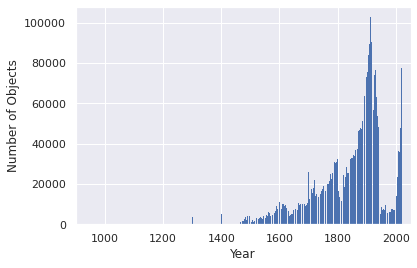

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn; seaborn.set()

def plot_year_count(year_count):
    labels, values = zip(*year_count.items())
    plt.xlim([900, 2050])
    plt.bar(labels, values, edgecolor='none')    
    plt.ylabel('Number of Objects')
    plt.xlabel('Year');
    plt.show()

plot_year_count(YEAR_COUNTER)

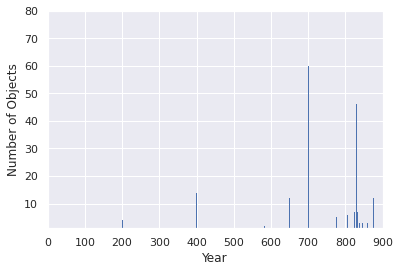

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn; seaborn.set()

def plot_year_count(year_count):
    labels, values = zip(*year_count.items())
    plt.xlim([0, 900])
    plt.ylim([1, 80])
    plt.bar(labels, values, edgecolor='none')    
    plt.ylabel('Number of Objects')
    plt.xlabel('Year');
    plt.show()

    
low_years = dict([(year, count) for year, count in YEAR_COUNTER.most_common() if year <900 and year > 0])
plot_year_count(low_years)

# PLACE